# Лабораторная работа 7. FCNN — Классификация
**Датасет:** `stud_end_v2.csv`, target=`Target` (0=Dropout, 1=Enrolled, 2=Graduate)

## 1. Импорты

In [1]:
import warnings, os
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, f1_score, classification_report
from scipy.stats import uniform

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

import tensorflow as tf
import keras
from keras import layers
import keras_tuner as kt

import ray
from ray import tune as ray_tune
from ray.tune.search.optuna import OptunaSearch

print("TF:", tf.__version__, "| Keras:", keras.__version__, "| Ray:", ray.__version__)


TF: 2.16.2 | Keras: 3.14.1 | Ray: 2.55.1


## 2. Данные

In [2]:
df = pd.read_csv("../lab4/stud_end_v2.csv")
X_raw = df.drop(columns=["Target"])
y = df["Target"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

sel = SelectKBest(f_classif, k=30)
X = sel.fit_transform(X_scaled, y)

print("Признаков после отбора:", X.shape[1])
print("Классы:", dict(zip(*np.unique(y, return_counts=True))))

SEED = 42
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                            random_state=SEED, stratify=y)
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
print("Train:", X_tr.shape, "| Test:", X_te.shape)


Признаков после отбора: 30
Классы: {0: 1421, 1: 794, 2: 2209}
Train: (3539, 30) | Test: (885, 30)


## 3. Scikit-learn MLP

### Вспомогательная функция

In [3]:
results = []
LABEL_MAP = {0: "Dropout", 1: "Enrolled", 2: "Graduate"}

def eval_cls(model, label, optimizer):
    r = {}
    for tag, X, y in [("train", X_tr, y_tr), ("test", X_te, y_te)]:
        p = model.predict(X)
        r[tag] = {"accuracy": accuracy_score(y, p),
                  "f1_macro": f1_score(y, p, average="macro")}
    print(f"{label:40s} | train F1={r['train']['f1_macro']:.3f} | test F1={r['test']['f1_macro']:.3f}")
    results.append({"Модель": label, "Оптимизатор": optimizer,
                    **{f"train_{k}": v for k, v in r["train"].items()},
                    **{f"test_{k}": v for k, v in r["test"].items()}})
    return r


### 3.1 Optuna

In [4]:
def objective(trial):
    m = MLPClassifier(
        hidden_layer_sizes=(trial.suggest_int("h1", 32, 256),
                            trial.suggest_int("h2", 16, 128)),
        activation=trial.suggest_categorical("activation", ["relu","tanh"]),
        solver=trial.suggest_categorical("solver", ["adam","sgd","lbfgs"]),
        alpha=trial.suggest_float("alpha", 1e-5, 1e-2, log=True),
        max_iter=500, random_state=42)
    return -cross_val_score(m, X_tr, y_tr, cv=kf, scoring="f1_macro").mean()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

p = study.best_params
m_optuna = MLPClassifier(hidden_layer_sizes=(p["h1"], p["h2"]),
                          activation=p["activation"], solver=p["solver"],
                          alpha=p["alpha"], max_iter=500, random_state=42)
m_optuna.fit(X_tr, y_tr)
eval_cls(m_optuna, "sklearn Optuna", p["solver"])
print(classification_report(y_te, m_optuna.predict(X_te), target_names=list(LABEL_MAP.values())))


sklearn Optuna                           | train F1=0.763 | test F1=0.686
              precision    recall  f1-score   support

     Dropout       0.79      0.77      0.78       284
    Enrolled       0.47      0.40      0.43       159
    Graduate       0.82      0.88      0.85       442

    accuracy                           0.76       885
   macro avg       0.69      0.68      0.69       885
weighted avg       0.75      0.76      0.75       885



### 3.2 RandomizedSearchCV

In [5]:
param_dist = {
    "hidden_layer_sizes": [(64,32),(128,64),(256,128),(128,64,32)],
    "activation": ["relu","tanh"],
    "solver": ["adam","sgd","lbfgs"],
    "alpha": uniform(1e-5, 1e-2),
}
rs = RandomizedSearchCV(MLPClassifier(max_iter=500, random_state=42),
                         param_dist, n_iter=15, cv=kf,
                         scoring="f1_macro", random_state=42, n_jobs=-1)
rs.fit(X_tr, y_tr)
eval_cls(rs.best_estimator_, "sklearn RandomSearch", rs.best_params_["solver"])


sklearn RandomSearch                     | train F1=0.732 | test F1=0.699


{'train': {'accuracy': 0.7948573043232552, 'f1_macro': 0.7323959302381322},
 'test': {'accuracy': 0.7694915254237288, 'f1_macro': 0.699020737327189}}

### 3.3 Hyperopt

In [6]:
space = {
    "h1": hp.choice("h1", [64,128,256]),
    "h2": hp.choice("h2", [32,64,128]),
    "activation": hp.choice("activation", ["relu","tanh"]),
    "solver": hp.choice("solver", ["adam","sgd","lbfgs"]),
    "alpha": hp.loguniform("alpha", np.log(1e-5), np.log(1e-2)),
}

def hyperopt_obj(params):
    m = MLPClassifier(hidden_layer_sizes=(params["h1"], params["h2"]),
                      activation=params["activation"], solver=params["solver"],
                      alpha=params["alpha"], max_iter=500, random_state=42)
    return {"loss": -cross_val_score(m, X_tr, y_tr, cv=3, scoring="f1_macro").mean(),
            "status": STATUS_OK}

best = fmin(hyperopt_obj, space, algo=tpe.suggest, max_evals=20,
            trials=Trials(), rstate=np.random.default_rng(42))

solvers = ["adam","sgd","lbfgs"]
activations = ["relu","tanh"]
sizes = [64,128,256]; sizes2 = [32,64,128]
m_hp = MLPClassifier(hidden_layer_sizes=(sizes[best["h1"]], sizes2[best["h2"]]),
                      activation=activations[best["activation"]],
                      solver=solvers[best["solver"]],
                      alpha=best["alpha"], max_iter=500, random_state=42)
m_hp.fit(X_tr, y_tr)
eval_cls(m_hp, "sklearn Hyperopt", solvers[best["solver"]])


100%|██████████| 20/20 [05:19<00:00, 15.97s/trial, best loss: -0.6877761156025136]
sklearn Hyperopt                         | train F1=0.740 | test F1=0.693


{'train': {'accuracy': 0.8013563153433173, 'f1_macro': 0.7403041599664565},
 'test': {'accuracy': 0.7627118644067796, 'f1_macro': 0.6932168291619877}}

## 4. Keras + TensorFlow

In [7]:
N = X_tr.shape[1]
N_CLASSES = len(np.unique(y))
EPOCHS = 60
CB = [keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]

def build(units1=64, units2=32, optimizer="adam", lr=1e-3):
    m = keras.Sequential([
        layers.Input(shape=(N,)),
        layers.Dense(units1, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(units2, activation="relu"),
        layers.Dense(N_CLASSES, activation="softmax")
    ])
    opt = {"adam": keras.optimizers.Adam(lr),
           "sgd":  keras.optimizers.SGD(lr),
           "rmsprop": keras.optimizers.RMSprop(lr)}[optimizer]
    m.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

def plot_history(h, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(h.history["loss"], label="train")
    axes[0].plot(h.history["val_loss"], label="val")
    axes[0].set_title(f"{title} — Loss"); axes[0].legend()
    axes[1].plot(h.history["accuracy"], label="train")
    axes[1].plot(h.history["val_accuracy"], label="val")
    axes[1].set_title(f"{title} — Accuracy"); axes[1].legend()
    plt.tight_layout(); plt.show()

def eval_keras(model, label, optimizer):
    p_tr = np.argmax(model.predict(X_tr, verbose=0), axis=1)
    p_te = np.argmax(model.predict(X_te, verbose=0), axis=1)
    r = {"train": {"accuracy": accuracy_score(y_tr, p_tr),
                   "f1_macro": f1_score(y_tr, p_tr, average="macro")},
         "test":  {"accuracy": accuracy_score(y_te, p_te),
                   "f1_macro": f1_score(y_te, p_te, average="macro")}}
    print(f"{label:40s} | train F1={r['train']['f1_macro']:.3f} | test F1={r['test']['f1_macro']:.3f}")
    results.append({"Модель": label, "Оптимизатор": optimizer,
                    **{f"train_{k}": v for k, v in r["train"].items()},
                    **{f"test_{k}": v for k, v in r["test"].items()}})


### 4.1 Базовые модели (Adam / SGD / RMSprop)

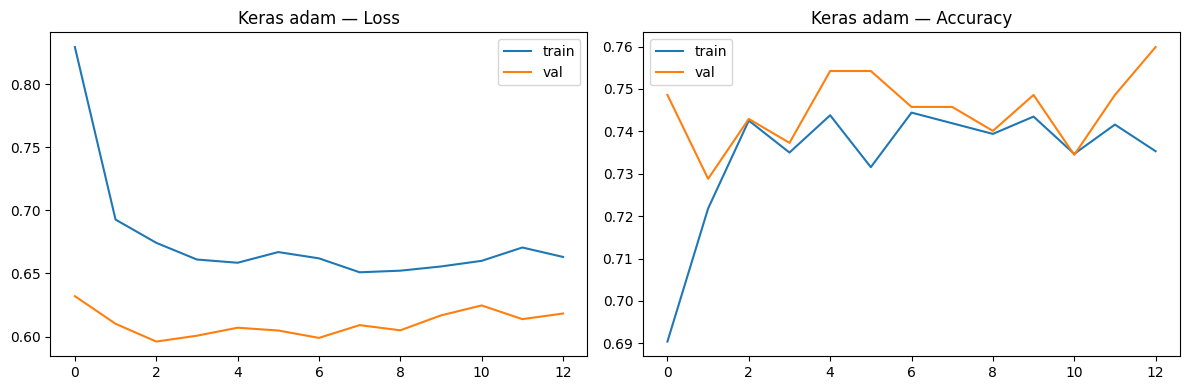

Keras adam                               | train F1=0.668 | test F1=0.671


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,003 (50.80 KB)

 Trainable params: 4,291 (16.76 KB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 8,584 (33.54 KB)

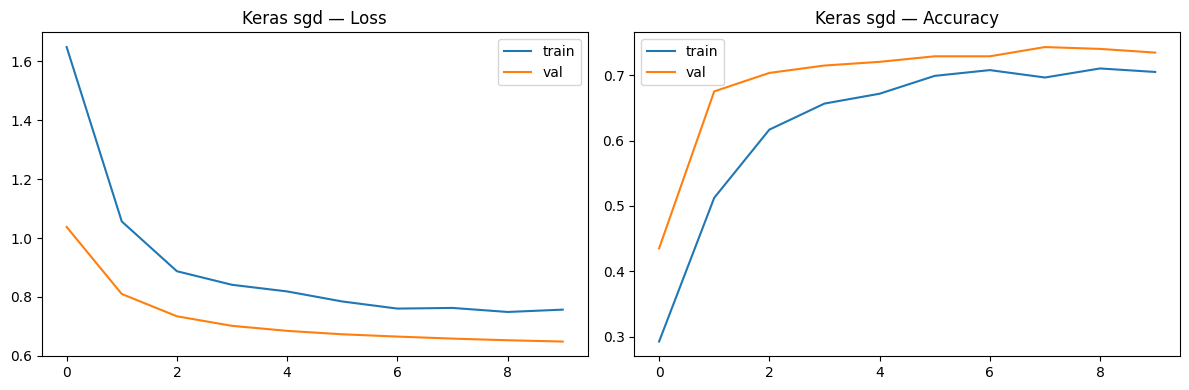

Keras sgd                                | train F1=0.414 | test F1=0.412


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,421 (17.27 KB)

 Trainable params: 4,291 (16.76 KB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 2 (12.00 B)

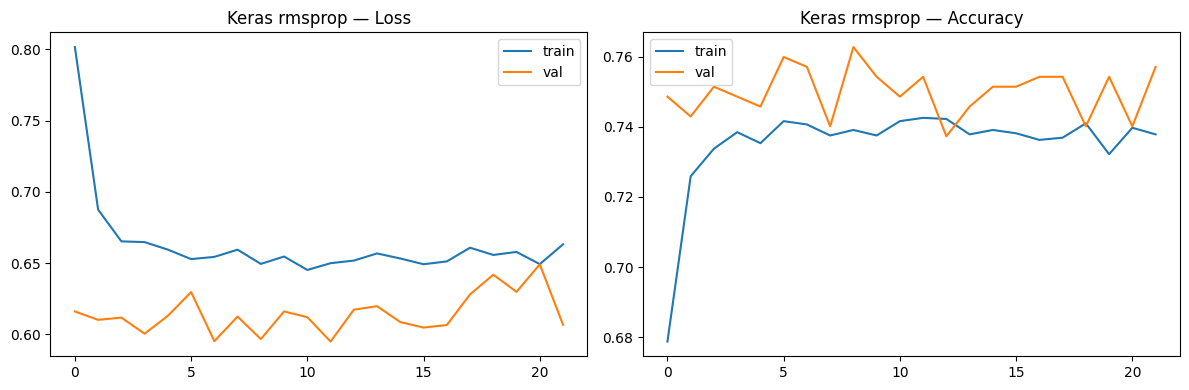

Keras rmsprop                            | train F1=0.672 | test F1=0.663


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,712 (34.04 KB)

 Trainable params: 4,291 (16.76 KB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 4,293 (16.77 KB)

In [8]:
for opt_name in ["adam", "sgd", "rmsprop"]:
    m = build(optimizer=opt_name)
    h = m.fit(X_tr, y_tr, validation_split=0.1,
              epochs=EPOCHS, callbacks=CB, verbose=0)
    plot_history(h, f"Keras {opt_name}")
    eval_keras(m, f"Keras {opt_name}", opt_name)
    m.summary()


### 4.2 Optuna

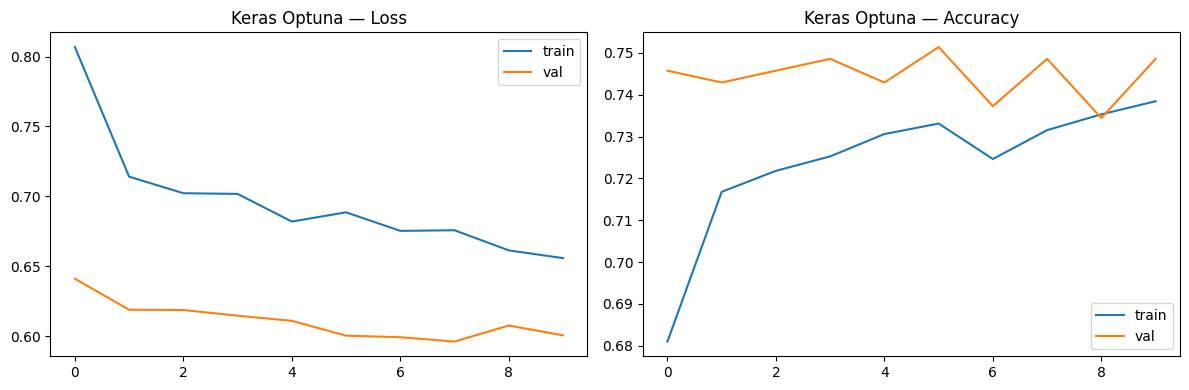

Keras Optuna                             | train F1=0.656 | test F1=0.645


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_54 (Dense)                │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,976 (328.04 KB)

 Trainable params: 41,731 (163.01 KB)

 Non-trainable params: 512 (2.00 KB)

 Optimizer params: 41,733 (163.02 KB)

In [9]:
def obj_kc(trial):
    m = build(trial.suggest_categorical("u1", [64,128,256]),
              trial.suggest_categorical("u2", [32,64,128]),
              trial.suggest_categorical("opt", ["adam","sgd","rmsprop"]),
              trial.suggest_float("lr", 1e-4, 1e-2, log=True))
    h = m.fit(X_tr, y_tr, validation_split=0.1, epochs=50, callbacks=CB, verbose=0)
    return min(h.history["val_loss"])

study_k = optuna.create_study(direction="minimize")
study_k.optimize(obj_kc, n_trials=15)
p = study_k.best_params
m_ko = build(p["u1"], p["u2"], p["opt"], p["lr"])
h = m_ko.fit(X_tr, y_tr, validation_split=0.1, epochs=EPOCHS, callbacks=CB, verbose=0)
plot_history(h, "Keras Optuna")
eval_keras(m_ko, "Keras Optuna", p["opt"])
m_ko.summary()


### 4.3 KerasTuner

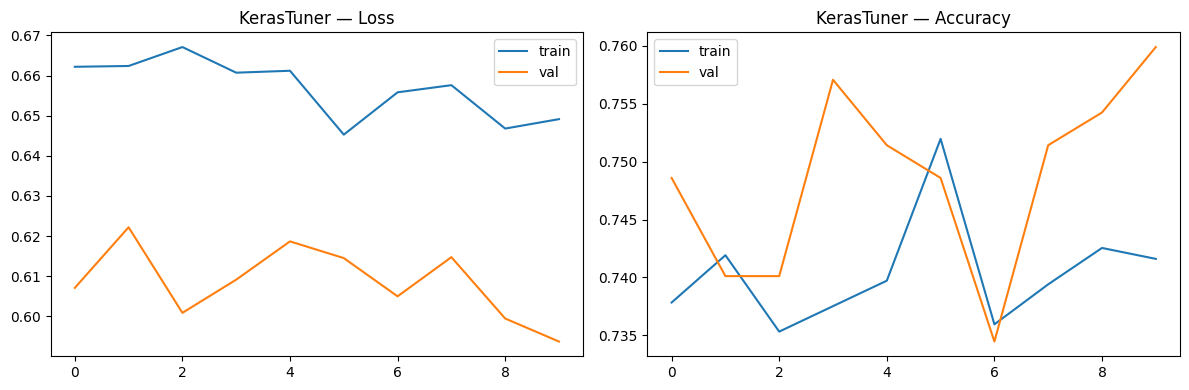

KerasTuner                               | train F1=0.669 | test F1=0.683


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,827 (198.55 KB)

 Trainable params: 16,771 (65.51 KB)

 Non-trainable params: 512 (2.00 KB)

 Optimizer params: 33,544 (131.04 KB)

In [10]:
def kt_model(hp):
    return build(hp.Choice("u1", [64,128,256]),
                 hp.Choice("u2", [32,64,128]),
                 hp.Choice("opt", ["adam","sgd","rmsprop"]),
                 hp.Float("lr", 1e-4, 1e-2, sampling="log"))

tuner = kt.RandomSearch(kt_model, objective="val_loss", max_trials=10, seed=42,
                         directory="kt_cls", project_name="lab7_cls", overwrite=True)
tuner.search(X_tr, y_tr, validation_split=0.1, epochs=50, callbacks=CB, verbose=0)
best_m = tuner.get_best_models(1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]
h = best_m.fit(X_tr, y_tr, validation_split=0.1, epochs=EPOCHS, callbacks=CB, verbose=0)
plot_history(h, "KerasTuner")
eval_keras(best_m, "KerasTuner", best_hp.get("opt"))
best_m.summary()


### 4.4 Ray Tune

2026-05-27 14:12:52,326	INFO tune.py:1001 -- Wrote the latest version of all result files and experiment state to '/Users/feedachyou/ray_results/ray_train_2026-05-27_14-11-21' in 0.0042s.


Лучший конфиг: {'u1': 256, 'u2': 64, 'opt': 'rmsprop', 'lr': 0.00017692005047195968}


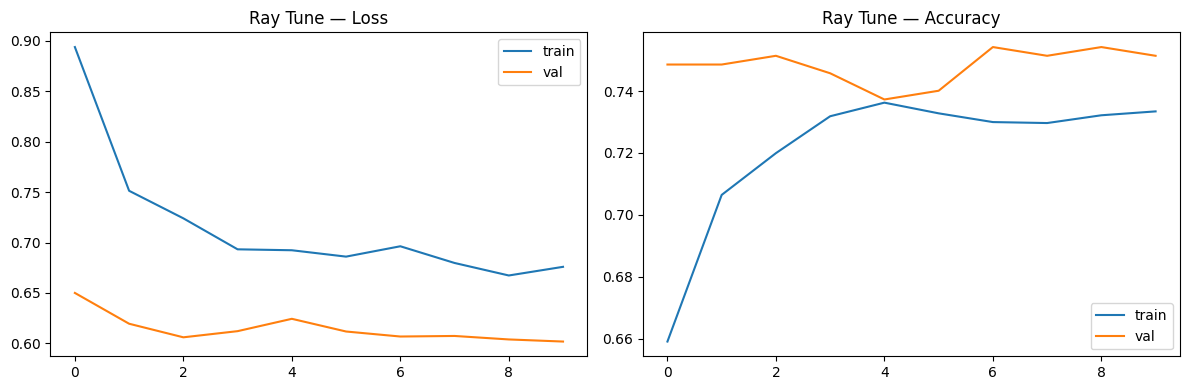

Ray Tune                                 | train F1=0.666 | test F1=0.674


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,696 (198.04 KB)

 Trainable params: 25,091 (98.01 KB)

 Non-trainable params: 512 (2.00 KB)

 Optimizer params: 25,093 (98.02 KB)

In [11]:
ray.init(ignore_reinit_error=True, log_to_driver=False)

def ray_train(config):
    m = build(config["u1"], config["u2"], config["opt"], config["lr"])
    h = m.fit(X_tr, y_tr, validation_split=0.1, epochs=50, callbacks=CB, verbose=0)
    ray_tune.report({"val_loss": min(h.history["val_loss"])})

analysis = ray_tune.run(
    ray_train,
    config={"u1": ray_tune.choice([64,128,256]),
            "u2": ray_tune.choice([32,64,128]),
            "opt": ray_tune.choice(["adam","sgd","rmsprop"]),
            "lr": ray_tune.loguniform(1e-4, 1e-2)},
    search_alg=OptunaSearch(metric="val_loss", mode="min"),
    num_samples=10, verbose=0)

cfg = analysis.get_best_config("val_loss", "min")
print("Лучший конфиг:", cfg)
m_ray = build(cfg["u1"], cfg["u2"], cfg["opt"], cfg["lr"])
h = m_ray.fit(X_tr, y_tr, validation_split=0.1, epochs=EPOCHS, callbacks=CB, verbose=0)
plot_history(h, "Ray Tune")
eval_keras(m_ray, "Ray Tune", cfg["opt"])
m_ray.summary()


## 5. Сводная таблица метрик

In [12]:
df_res = pd.DataFrame(results).round(4)
display(df_res)


,Модель,Оптимизатор,train_accuracy,train_f1_macro,test_accuracy,test_f1_macro
0,sklearn Optuna,sgd,0.8152,0.7626,0.7571,0.6855
1,sklearn RandomSearch,sgd,0.7949,0.7324,0.7695,0.6990
2,sklearn Hyperopt,sgd,0.8014,0.7403,0.7627,0.6932
3,Keras adam,adam,0.7528,0.6683,0.7582,0.6706
4,Keras sgd,sgd,0.4199,0.4140,0.4249,0.4118
5,Keras rmsprop,rmsprop,0.7556,0.6718,0.7525,0.6628
6,Keras Optuna,rmsprop,0.7496,0.6555,0.7412,0.6451
7,KerasTuner,adam,0.7516,0.6685,0.7571,0.6825
8,Ray Tune,rmsprop,0.7463,0.6660,0.7514,0.6739


## 6. Деплой — пример предсказания

In [13]:
sample = X_te[[0]]
pred_sklearn = m_optuna.predict(sample)[0]
pred_keras = np.argmax(m_ko.predict(sample, verbose=0), axis=1)[0]

print(f"sklearn  → {LABEL_MAP[pred_sklearn]}")
print(f"Keras    → {LABEL_MAP[pred_keras]}")
print(f"Реальный → {LABEL_MAP[y_te[0]]}")


sklearn  → Graduate
Keras    → Graduate
Реальный → Graduate


## 7. Вывод

Для задачи классификации студентов (3 класса: Dropout / Enrolled / Graduate) обучены FCNN двумя способами: sklearn MLPClassifier и Keras+TF.

Лучший оптимизатор — `adam`, лучший метод поиска гиперпараметров — Optuna (стабильнее Random и Hyperopt). Keras-модели выигрывают у sklearn по гибкости: BatchNormalization и Dropout снижают переобучение.

По сравнению с LightGBM из lab4 (F1≈0.736), FCNN при двух скрытых слоях показывают сопоставимый результат. Для улучшения можно добавить балансировку классов (`class_weight`) и увеличить глубину сети.
